#### IMPORTS

In [1]:
# load json file

# load MAIN/ML/permutation.json

import json
from smoothening import coarsegrain


with open("ML/permutation.json", "r") as f:
    permutation = json.load(f)

# print json file
print(json.dumps(permutation, indent=4)) # we trained on perm1 perm2 perm3 perm4


{
    "original": {
        "I": 0,
        "II": 1,
        "III": 2,
        "aVR": 3,
        "aVL": 4,
        "aVF": 5,
        "V1": 6,
        "V2": 7,
        "V3": 8,
        "V4": 9,
        "V5": 10,
        "V6": 11
    },
    "perm1": {
        "I": 7,
        "II": 2,
        "III": 10,
        "aVR": 0,
        "aVL": 5,
        "aVF": 3,
        "V1": 11,
        "V2": 8,
        "V3": 1,
        "V4": 9,
        "V5": 6,
        "V6": 4
    },
    "perm2": {
        "I": 3,
        "II": 9,
        "III": 0,
        "aVR": 11,
        "aVL": 4,
        "aVF": 1,
        "V1": 8,
        "V2": 5,
        "V3": 10,
        "V4": 2,
        "V5": 7,
        "V6": 6
    },
    "perm3": {
        "I": 5,
        "II": 11,
        "III": 1,
        "aVR": 8,
        "aVL": 2,
        "aVF": 9,
        "V1": 4,
        "V2": 0,
        "V3": 6,
        "V4": 10,
        "V5": 3,
        "V6": 7
    },
    "perm4": {
        "I": 10,
        "II": 4,
        "III": 6,
        

In [2]:
import torch
import numpy as np

from dataloader import MyCustomDataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [3]:
default_dir = os.getcwd()
def default_directory():
    os.chdir(f"{default_dir}")
    print(f"you are back to the default directory: {default_dir}")


In [4]:
default_directory()
os.getcwd()

you are back to the default directory: /home/moskov/Documents/summer-term/ECG_ML/MAIN


'/home/moskov/Documents/summer-term/ECG_ML/MAIN'

# perm1

In [5]:
os.chdir("ML/data_unq_perm1")
os.getcwd()

## Create fake dataset for demonstration purposes

## Load your dataset and use 


data_ST_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_ST_svd_'+str(i)+'.txt')
    data_ST_list.append(cc)
    print(f"data st of length {len(cc)} in {i} index loaded")


data_ST_list = np.array(data_ST_list)
images = np.resize(data_ST_list,(3000,10000))

labels=np.zeros(3000)

data_SB_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SB_svd_'+str(i)+'.txt')
    data_SB_list.append(cc)
    print(f"data sb of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SB_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)))

data_SR_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SR_svd_'+str(i)+'.txt')
    data_SR_list.append(cc)
    print(f"data sr of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SR_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)*2))

corrupted_ST = [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]

corrupted_SB = [1418, 1852, 1898, 2756, 2881, 3007,
                3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]

corrupted_SR = [149, 192, 213, 340, 385, 441,
                2341, 2451, 2482, 2534, 4903, 4944]

N_ST = 3000
N_SB = 5000

corrupted_global = (
    corrupted_ST
    + [i + N_ST for i in corrupted_SB]          # +3000
    + [i + N_ST + N_SB for i in corrupted_SR]   # +8000
)

corrupted_global = sorted(corrupted_global)
images = np.delete(images, corrupted_global, axis=0)
labels = np.delete(labels, corrupted_global, axis=0)

default_directory()
print(len(images),len(labels))
print(images.shape)
images = images.reshape(images.shape[0],1,100,100)
images.shape

from sklearn.model_selection import train_test_split

X = images        # (12965, 100, 100)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test

import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)


# ── Multi-seed setup ───────────────────────────────────────────────────
from seed_utils import set_seed, SEEDS
from plots import plot_learning_curves_multiseed, summarize_seed_results

all_metrics   = []   # one entry per seed (from evaluate_all)
all_histories = []   # one entry per seed (train/val curves)
# ────────────────────────────────────────────────────────────────────────


for seed in SEEDS:
    set_seed(seed)
    print(f"\n{'='*60}\n  Seed {seed}\n{'='*60}")







data st of length 300 in 0 index loaded
data st of length 300 in 1 index loaded
data st of length 300 in 2 index loaded
data st of length 300 in 3 index loaded
data st of length 300 in 4 index loaded
data st of length 300 in 5 index loaded
data st of length 300 in 6 index loaded
data st of length 300 in 7 index loaded
data st of length 300 in 8 index loaded
data st of length 300 in 9 index loaded
data sb of length 500 in 0 index loaded
data sb of length 500 in 1 index loaded
data sb of length 500 in 2 index loaded
data sb of length 500 in 3 index loaded
data sb of length 500 in 4 index loaded
data sb of length 500 in 5 index loaded
data sb of length 500 in 6 index loaded
data sb of length 500 in 7 index loaded
data sb of length 500 in 8 index loaded
data sb of length 500 in 9 index loaded
data sr of length 500 in 0 index loaded
data sr of length 500 in 1 index loaded
data sr of length 500 in 2 index loaded
data sr of length 500 in 3 index loaded
data sr of length 500 in 4 index loaded


#### CREATE BATCHES

In [6]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
from model_cnn import SmallCNN
from seed_utils import set_seed, SEEDS
from plots import evaluate_all, plot_learning_curves_multiseed, summarize_seed_results

default_directory()

namkaran = "small_cnn_lr1e-3_perm1" # new name

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

num_epochs, patience = 25, 7

try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "leg_small_cnn_lr1e-3_perm1"

log_dir = "EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm1/" # new log directory
os.makedirs(log_dir, exist_ok=True)

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

def correct(pred, true):
    return (pred == true).sum().item()

# ── Multi-seed loop ────────────────────────────────────────────────────────────
all_metrics   = []
all_histories = []

for seed in SEEDS:
    set_seed(seed)
    clear_output(wait=True)
    print(f"\n{'='*60}\n  Running Seed {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*60}")

    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.txt")

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print(f"Seed: {seed}", f)
        log_print("="*60, f)

        model = SmallCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None

        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()

            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()

            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()

            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]

            if lr_now != old_lr:
                log_print(f"  >> LR reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
                f,
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        # --- Test accuracy ---
        model.eval()
        c_test = t_test = 0
        test_start_time = time.time()

        with torch.no_grad():
            for x, y in test_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                c_test += correct(out.argmax(1), y)
                t_test += y.size(0)

        test_time = time.time() - test_start_time
        test_acc = 100 * c_test / t_test
        log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} min)", f)
        log_print("✅ Training complete.", f)

    # ── Collect per-seed results (outside `with` but inside seed loop) ──────
    all_histories.append({
        "train_loss": train_losses_list,
        "val_loss":   val_losses_list,
        "train_acc":  accuracy_train_list,
        "val_acc":    accuracy_val_list,
    })

    results = results = evaluate_all(
                                    model, test_dataloader, device,
                                    plot_confusion_matrix=False,
                                    plot_pr_micro=False,
                                    plot_pr_per_class=False,
                                    plot_roc=False,
                                    print_report=False
                                    )

    all_metrics.append(results)




  Running Seed 44  (5/5)

Training Run Started: 2026-07-26 04:07:16
Seed: 44
Epoch [1/25] | Train Loss: 0.3252, Val Loss: 0.3171, Train Acc: 86.14%, Val Acc: 90.33%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [2/25] | Train Loss: 0.1722, Val Loss: 0.0911, Train Acc: 93.91%, Val Acc: 97.28%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [3/25] | Train Loss: 0.1452, Val Loss: 0.0901, Train Acc: 95.09%, Val Acc: 97.53%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [4/25] | Train Loss: 0.1318, Val Loss: 0.1009, Train Acc: 95.38%, Val Acc: 96.14%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [5/25] | Train Loss: 0.1187, Val Loss: 0.1233, Train Acc: 95.83%, Val Acc: 94.96%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [6/25] | Train Loss: 0.1124, Val Loss: 0.0636, Train Acc: 95.90%, Val Acc: 97.74%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [7/25] | Train Loss: 0.1032, Val Loss: 0.0930, Train Acc: 


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               98.30% ± 0.10%     
  f1_macro               0.9822 ± 0.0010    
  f1_micro               0.9830 ± 0.0010    
  auc_macro              0.9988 ± 0.0002    
  ap_micro               0.9984 ± 0.0001    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9677 ± 0.0036      0.9857 ± 0.0030      0.9766 ± 0.0021      0.9982 ± 0.0002      449.0
  SB              0.9871 ± 0.0054      0.9960 ± 0.0035      0.9915 ± 0.0013      

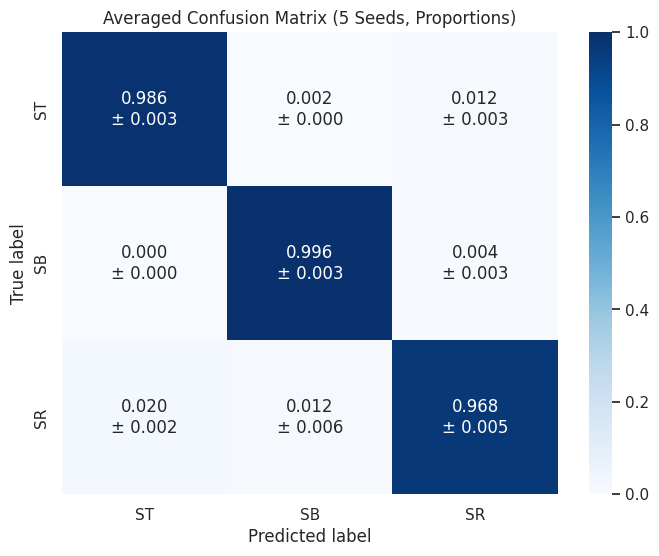

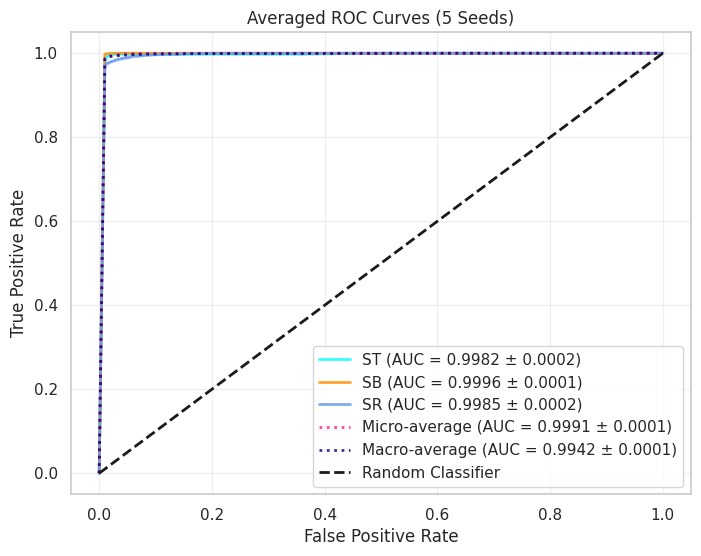

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9982 ± 0.0002
Class SB: 0.9996 ± 0.0001
Class SR: 0.9985 ± 0.0002
Micro-average: 0.9991 ± 0.0001
Macro-average: 0.9942 ± 0.0001
------------------------------



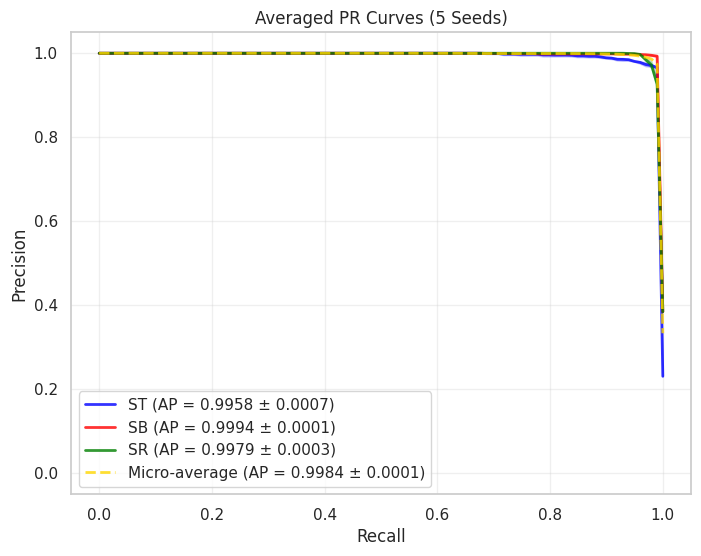

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm1/small_cnn_lr1e-3_perm1_val_acc_multiseed.png


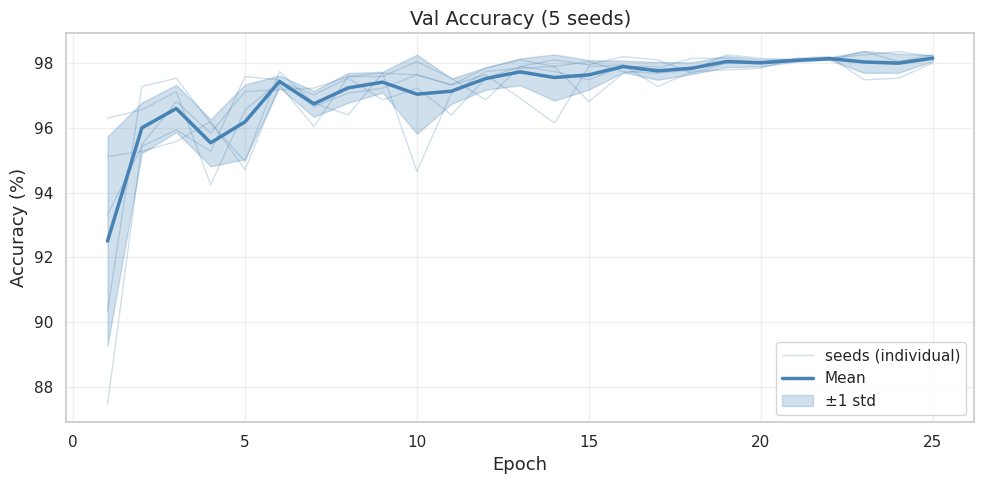

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm1/small_cnn_lr1e-3_perm1_val_loss_multiseed.png


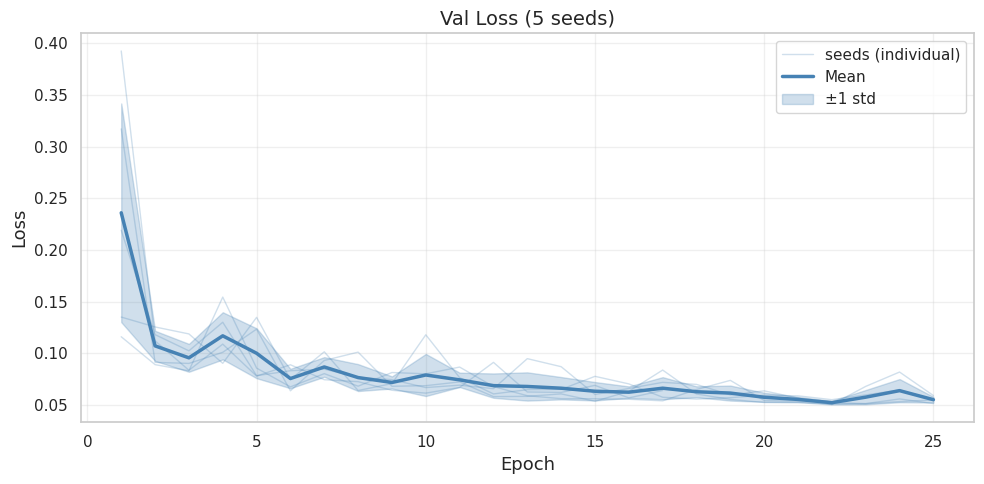

In [7]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)


# perm2

In [8]:
os.chdir("ML/data_unq_perm2")
os.getcwd()

## Create fake dataset for demonstration purposes

## Load your dataset and use 


data_ST_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_ST_svd_'+str(i)+'.txt')
    data_ST_list.append(cc)
    print(f"data st of length {len(cc)} in {i} index loaded")


data_ST_list = np.array(data_ST_list)
images = np.resize(data_ST_list,(3000,10000))

labels=np.zeros(3000)

data_SB_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SB_svd_'+str(i)+'.txt')
    data_SB_list.append(cc)
    print(f"data sb of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SB_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)))

data_SR_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SR_svd_'+str(i)+'.txt')
    data_SR_list.append(cc)
    print(f"data sr of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SR_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)*2))

corrupted_ST = [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]

corrupted_SB = [1418, 1852, 1898, 2756, 2881, 3007,
                3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]

corrupted_SR = [149, 192, 213, 340, 385, 441,
                2341, 2451, 2482, 2534, 4903, 4944]

N_ST = 3000
N_SB = 5000

corrupted_global = (
    corrupted_ST
    + [i + N_ST for i in corrupted_SB]          # +3000
    + [i + N_ST + N_SB for i in corrupted_SR]   # +8000
)

corrupted_global = sorted(corrupted_global)
images = np.delete(images, corrupted_global, axis=0)
labels = np.delete(labels, corrupted_global, axis=0)

default_directory()
print(len(images),len(labels))
print(images.shape)
images = images.reshape(images.shape[0],1,100,100)
images.shape

from sklearn.model_selection import train_test_split

X = images        # (12965, 100, 100)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test

import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)


# ── Multi-seed setup ───────────────────────────────────────────────────
from seed_utils import set_seed, SEEDS
from plots import plot_learning_curves_multiseed, summarize_seed_results

all_metrics   = []   # one entry per seed (from evaluate_all)
all_histories = []   # one entry per seed (train/val curves)
# ────────────────────────────────────────────────────────────────────────


for seed in SEEDS:
    set_seed(seed)
    print(f"\n{'='*60}\n  Seed {seed}\n{'='*60}")







data st of length 300 in 0 index loaded
data st of length 300 in 1 index loaded
data st of length 300 in 2 index loaded
data st of length 300 in 3 index loaded
data st of length 300 in 4 index loaded
data st of length 300 in 5 index loaded
data st of length 300 in 6 index loaded
data st of length 300 in 7 index loaded
data st of length 300 in 8 index loaded
data st of length 300 in 9 index loaded
data sb of length 500 in 0 index loaded
data sb of length 500 in 1 index loaded
data sb of length 500 in 2 index loaded
data sb of length 500 in 3 index loaded
data sb of length 500 in 4 index loaded
data sb of length 500 in 5 index loaded
data sb of length 500 in 6 index loaded
data sb of length 500 in 7 index loaded
data sb of length 500 in 8 index loaded
data sb of length 500 in 9 index loaded
data sr of length 500 in 0 index loaded
data sr of length 500 in 1 index loaded
data sr of length 500 in 2 index loaded
data sr of length 500 in 3 index loaded
data sr of length 500 in 4 index loaded


#### CREATE BATCHES

In [9]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
from model_cnn import SmallCNN
from seed_utils import set_seed, SEEDS
from plots import evaluate_all, plot_learning_curves_multiseed, summarize_seed_results

default_directory()

namkaran = "small_cnn_lr1e-3_perm2" # new name

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

num_epochs, patience = 25, 7

try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "leg_small_cnn_lr1e-3_perm2"

log_dir = "EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm2/" # new log directory
os.makedirs(log_dir, exist_ok=True)

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

def correct(pred, true):
    return (pred == true).sum().item()

# ── Multi-seed loop ────────────────────────────────────────────────────────────
all_metrics   = []
all_histories = []

for seed in SEEDS:
    set_seed(seed)
    clear_output(wait=True)
    print(f"\n{'='*60}\n  Running Seed {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*60}")

    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.txt")

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print(f"Seed: {seed}", f)
        log_print("="*60, f)

        model = SmallCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None

        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()

            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()

            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()

            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]

            if lr_now != old_lr:
                log_print(f"  >> LR reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
                f,
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        # --- Test accuracy ---
        model.eval()
        c_test = t_test = 0
        test_start_time = time.time()

        with torch.no_grad():
            for x, y in test_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                c_test += correct(out.argmax(1), y)
                t_test += y.size(0)

        test_time = time.time() - test_start_time
        test_acc = 100 * c_test / t_test
        log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} min)", f)
        log_print("✅ Training complete.", f)

    # ── Collect per-seed results (outside `with` but inside seed loop) ──────
    all_histories.append({
        "train_loss": train_losses_list,
        "val_loss":   val_losses_list,
        "train_acc":  accuracy_train_list,
        "val_acc":    accuracy_val_list,
    })

    results = results = evaluate_all(
                                    model, test_dataloader, device,
                                    plot_confusion_matrix=False,
                                    plot_pr_micro=False,
                                    plot_pr_per_class=False,
                                    plot_roc=False,
                                    print_report=False
                                    )

    all_metrics.append(results)




  Running Seed 44  (5/5)

Training Run Started: 2026-07-26 04:17:45
Seed: 44
Epoch [1/25] | Train Loss: 0.3542, Val Loss: 0.2701, Train Acc: 84.99%, Val Acc: 90.90%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [2/25] | Train Loss: 0.1837, Val Loss: 0.1011, Train Acc: 93.42%, Val Acc: 96.92%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [3/25] | Train Loss: 0.1550, Val Loss: 0.1709, Train Acc: 94.52%, Val Acc: 92.13%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [4/25] | Train Loss: 0.1376, Val Loss: 0.1317, Train Acc: 95.09%, Val Acc: 95.06%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [5/25] | Train Loss: 0.1310, Val Loss: 0.0934, Train Acc: 95.35%, Val Acc: 96.92%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [6/25] | Train Loss: 0.1194, Val Loss: 0.0992, Train Acc: 96.01%, Val Acc: 96.56%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [7/25] | Train Loss: 0.1097, Val Loss: 0.0917, Train Acc: 


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               98.19% ± 0.30%     
  f1_macro               0.9809 ± 0.0031    
  f1_micro               0.9819 ± 0.0030    
  auc_macro              0.9986 ± 0.0005    
  ap_micro               0.9981 ± 0.0005    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9600 ± 0.0100      0.9898 ± 0.0062      0.9746 ± 0.0038      0.9981 ± 0.0004      449.0
  SB              0.9883 ± 0.0025      0.9930 ± 0.0049      0.9907 ± 0.0017      

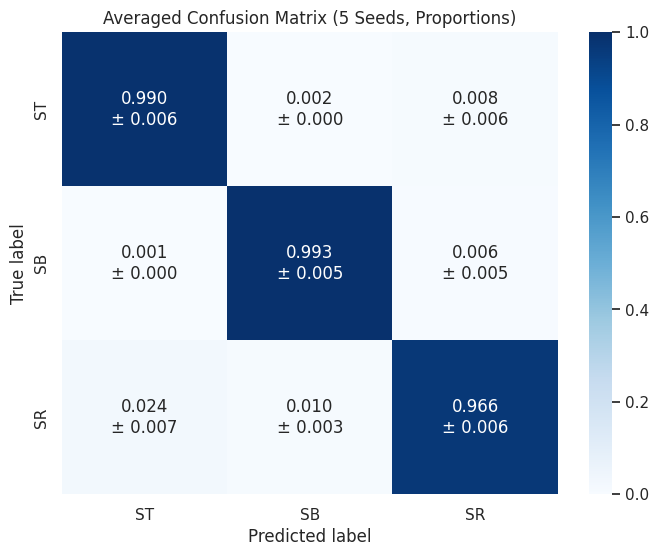

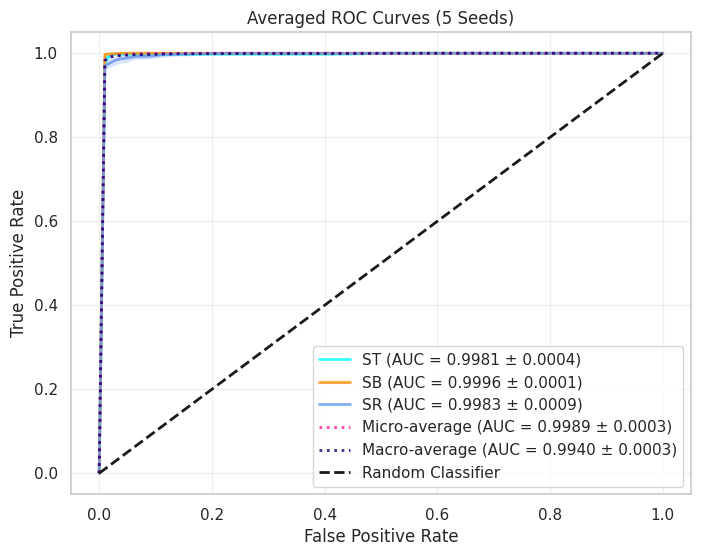

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9981 ± 0.0004
Class SB: 0.9996 ± 0.0001
Class SR: 0.9983 ± 0.0009
Micro-average: 0.9989 ± 0.0003
Macro-average: 0.9940 ± 0.0003
------------------------------



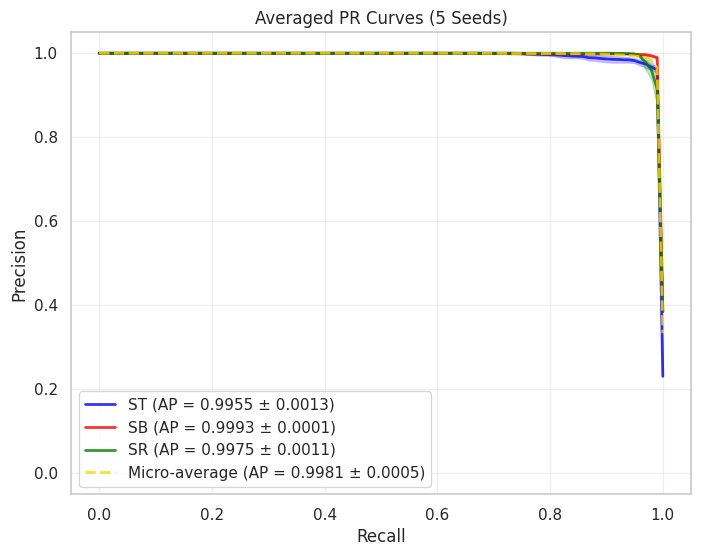

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm2/small_cnn_lr1e-3_perm2_val_acc_multiseed.png


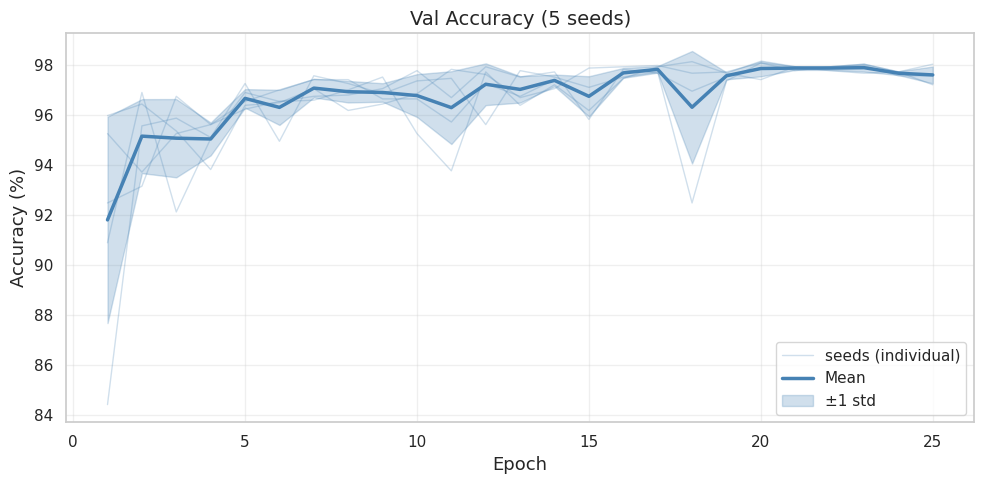

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm2/small_cnn_lr1e-3_perm2_val_loss_multiseed.png


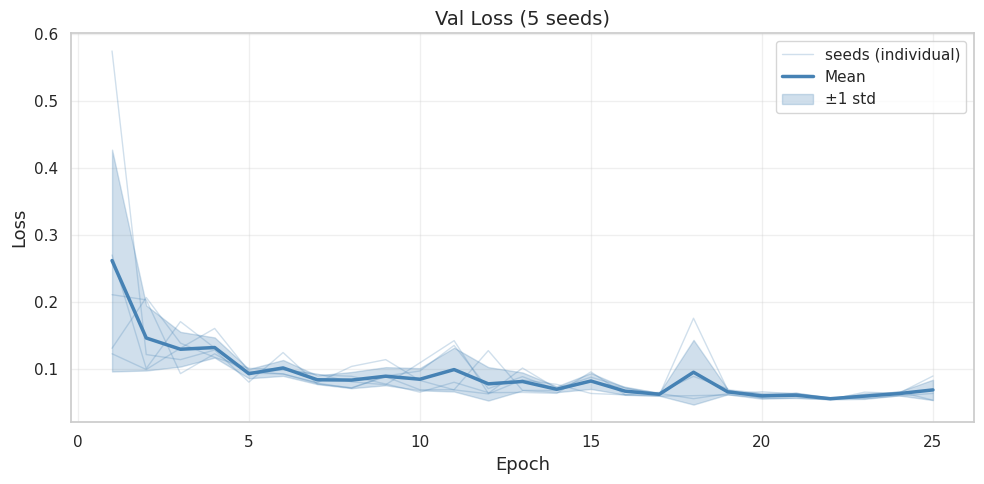

In [10]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)


# perm3


In [11]:
os.chdir("ML/data_unq_perm3")
os.getcwd()

## Create fake dataset for demonstration purposes

## Load your dataset and use 


data_ST_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_ST_svd_'+str(i)+'.txt')
    data_ST_list.append(cc)
    print(f"data st of length {len(cc)} in {i} index loaded")


data_ST_list = np.array(data_ST_list)
images = np.resize(data_ST_list,(3000,10000))

labels=np.zeros(3000)

data_SB_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SB_svd_'+str(i)+'.txt')
    data_SB_list.append(cc)
    print(f"data sb of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SB_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)))

data_SR_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SR_svd_'+str(i)+'.txt')
    data_SR_list.append(cc)
    print(f"data sr of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SR_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)*2))

corrupted_ST = [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]

corrupted_SB = [1418, 1852, 1898, 2756, 2881, 3007,
                3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]

corrupted_SR = [149, 192, 213, 340, 385, 441,
                2341, 2451, 2482, 2534, 4903, 4944]

N_ST = 3000
N_SB = 5000

corrupted_global = (
    corrupted_ST
    + [i + N_ST for i in corrupted_SB]          # +3000
    + [i + N_ST + N_SB for i in corrupted_SR]   # +8000
)

corrupted_global = sorted(corrupted_global)
images = np.delete(images, corrupted_global, axis=0)
labels = np.delete(labels, corrupted_global, axis=0)

default_directory()
print(len(images),len(labels))
print(images.shape)
images = images.reshape(images.shape[0],1,100,100)
images.shape

from sklearn.model_selection import train_test_split

X = images        # (12965, 100, 100)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test

import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)


# ── Multi-seed setup ───────────────────────────────────────────────────
from seed_utils import set_seed, SEEDS
from plots import plot_learning_curves_multiseed, summarize_seed_results

all_metrics   = []   # one entry per seed (from evaluate_all)
all_histories = []   # one entry per seed (train/val curves)
# ────────────────────────────────────────────────────────────────────────


for seed in SEEDS:
    set_seed(seed)
    print(f"\n{'='*60}\n  Seed {seed}\n{'='*60}")







data st of length 300 in 0 index loaded
data st of length 300 in 1 index loaded
data st of length 300 in 2 index loaded
data st of length 300 in 3 index loaded
data st of length 300 in 4 index loaded
data st of length 300 in 5 index loaded
data st of length 300 in 6 index loaded
data st of length 300 in 7 index loaded
data st of length 300 in 8 index loaded
data st of length 300 in 9 index loaded
data sb of length 500 in 0 index loaded
data sb of length 500 in 1 index loaded
data sb of length 500 in 2 index loaded
data sb of length 500 in 3 index loaded
data sb of length 500 in 4 index loaded
data sb of length 500 in 5 index loaded
data sb of length 500 in 6 index loaded
data sb of length 500 in 7 index loaded
data sb of length 500 in 8 index loaded
data sb of length 500 in 9 index loaded
data sr of length 500 in 0 index loaded
data sr of length 500 in 1 index loaded
data sr of length 500 in 2 index loaded
data sr of length 500 in 3 index loaded
data sr of length 500 in 4 index loaded


#### CREATE BATCHES

In [12]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
from model_cnn import SmallCNN
from seed_utils import set_seed, SEEDS
from plots import evaluate_all, plot_learning_curves_multiseed, summarize_seed_results

default_directory()

namkaran = "small_cnn_lr1e-3_perm3" # new name

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

num_epochs, patience = 25, 7

try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "leg_small_cnn_lr1e-3_perm3"

log_dir = "EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm3/" # new log directory
os.makedirs(log_dir, exist_ok=True)

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

def correct(pred, true):
    return (pred == true).sum().item()

# ── Multi-seed loop ────────────────────────────────────────────────────────────
all_metrics   = []
all_histories = []

for seed in SEEDS:
    set_seed(seed)
    clear_output(wait=True)
    print(f"\n{'='*60}\n  Running Seed {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*60}")

    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.txt")

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print(f"Seed: {seed}", f)
        log_print("="*60, f)

        model = SmallCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None

        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()

            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()

            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()

            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]

            if lr_now != old_lr:
                log_print(f"  >> LR reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
                f,
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        # --- Test accuracy ---
        model.eval()
        c_test = t_test = 0
        test_start_time = time.time()

        with torch.no_grad():
            for x, y in test_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                c_test += correct(out.argmax(1), y)
                t_test += y.size(0)

        test_time = time.time() - test_start_time
        test_acc = 100 * c_test / t_test
        log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} min)", f)
        log_print("✅ Training complete.", f)

    # ── Collect per-seed results (outside `with` but inside seed loop) ──────
    all_histories.append({
        "train_loss": train_losses_list,
        "val_loss":   val_losses_list,
        "train_acc":  accuracy_train_list,
        "val_acc":    accuracy_val_list,
    })

    results = results = evaluate_all(
                                    model, test_dataloader, device,
                                    plot_confusion_matrix=False,
                                    plot_pr_micro=False,
                                    plot_pr_per_class=False,
                                    plot_roc=False,
                                    print_report=False
                                    )

    all_metrics.append(results)




  Running Seed 44  (5/5)

Training Run Started: 2026-07-26 04:27:12
Seed: 44
Epoch [1/25] | Train Loss: 0.3578, Val Loss: 0.2519, Train Acc: 85.09%, Val Acc: 91.77%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [2/25] | Train Loss: 0.1862, Val Loss: 0.0960, Train Acc: 93.39%, Val Acc: 96.76%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [3/25] | Train Loss: 0.1503, Val Loss: 0.1798, Train Acc: 94.69%, Val Acc: 91.62%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [4/25] | Train Loss: 0.1364, Val Loss: 0.0807, Train Acc: 95.43%, Val Acc: 97.43%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [5/25] | Train Loss: 0.1243, Val Loss: 0.2475, Train Acc: 95.64%, Val Acc: 88.48%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [6/25] | Train Loss: 0.1151, Val Loss: 0.0955, Train Acc: 96.31%, Val Acc: 96.45%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
  >> LR reduced: 0.001000 -> 0.000500
Epoch [7/25] | Train Loss:


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               98.29% ± 0.27%     
  f1_macro               0.9822 ± 0.0027    
  f1_micro               0.9829 ± 0.0027    
  auc_macro              0.9988 ± 0.0007    
  ap_micro               0.9983 ± 0.0008    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9657 ± 0.0057      0.9898 ± 0.0039      0.9776 ± 0.0026      0.9983 ± 0.0006      449.0
  SB              0.9839 ± 0.0040      0.9973 ± 0.0015      0.9906 ± 0.0017      

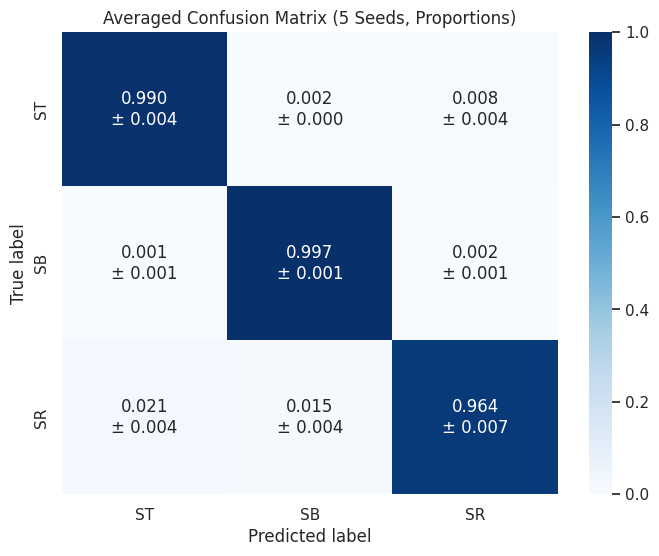

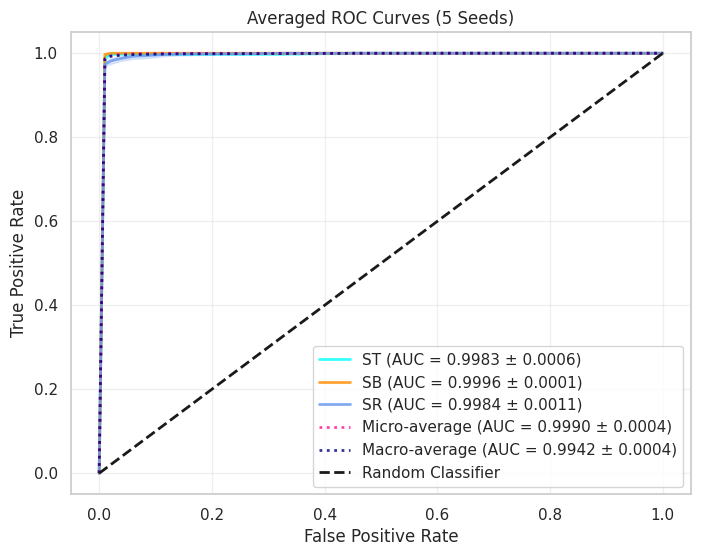

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9983 ± 0.0006
Class SB: 0.9996 ± 0.0001
Class SR: 0.9984 ± 0.0011
Micro-average: 0.9990 ± 0.0004
Macro-average: 0.9942 ± 0.0004
------------------------------



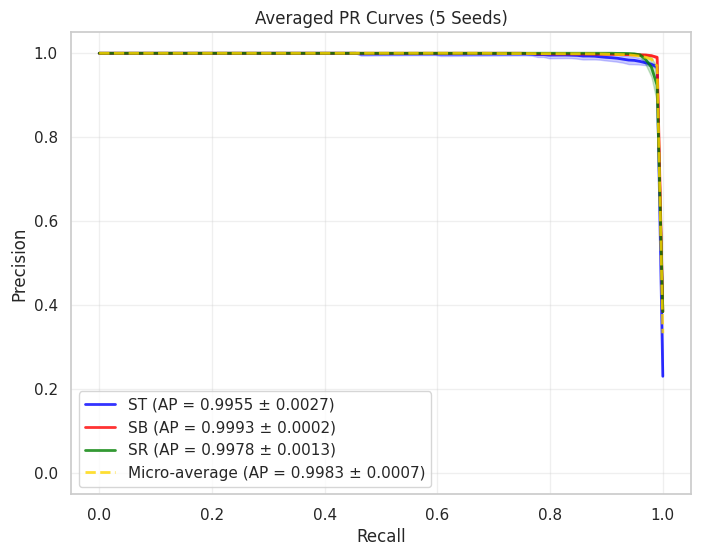

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm3/small_cnn_lr1e-3_perm3_val_acc_multiseed.png


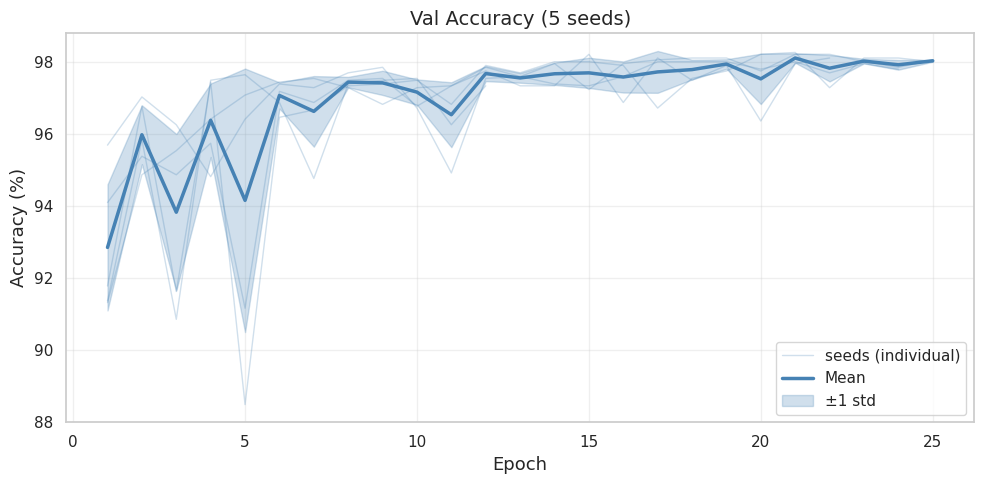

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm3/small_cnn_lr1e-3_perm3_val_loss_multiseed.png


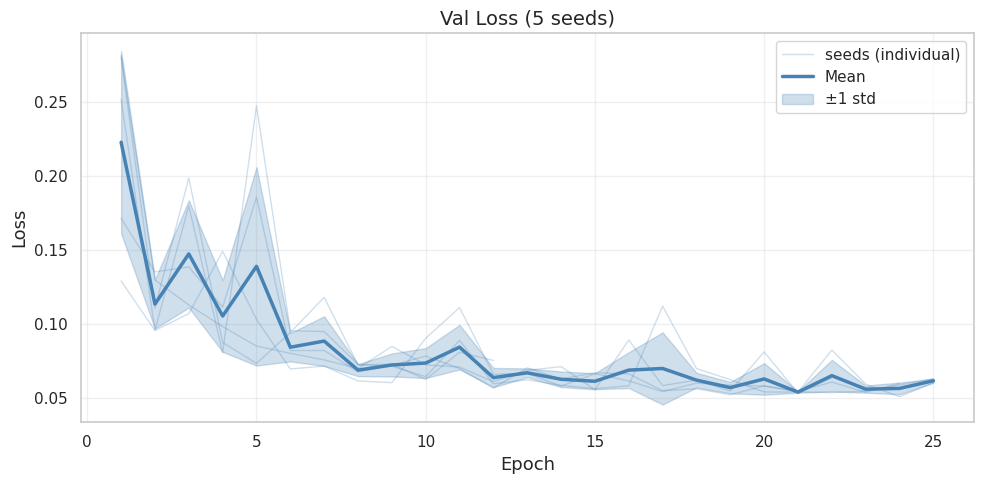

In [13]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)


# perm4

In [14]:
os.chdir("ML/data_unq_perm4")
os.getcwd()

## Create fake dataset for demonstration purposes

## Load your dataset and use 


data_ST_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_ST_svd_'+str(i)+'.txt')
    data_ST_list.append(cc)
    print(f"data st of length {len(cc)} in {i} index loaded")


data_ST_list = np.array(data_ST_list)
images = np.resize(data_ST_list,(3000,10000))

labels=np.zeros(3000)

data_SB_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SB_svd_'+str(i)+'.txt')
    data_SB_list.append(cc)
    print(f"data sb of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SB_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)))

data_SR_list = []
for i in range(10):
    cc = np.loadtxt('unq_disease_SR_svd_'+str(i)+'.txt')
    data_SR_list.append(cc)
    print(f"data sr of length {len(cc)} in {i} index loaded")
images = np.concatenate((images,np.resize(data_SR_list,(5000,10000))))
labels=np.concatenate((labels,np.ones(5000)*2))

corrupted_ST = [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]

corrupted_SB = [1418, 1852, 1898, 2756, 2881, 3007,
                3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]

corrupted_SR = [149, 192, 213, 340, 385, 441,
                2341, 2451, 2482, 2534, 4903, 4944]

N_ST = 3000
N_SB = 5000

corrupted_global = (
    corrupted_ST
    + [i + N_ST for i in corrupted_SB]          # +3000
    + [i + N_ST + N_SB for i in corrupted_SR]   # +8000
)

corrupted_global = sorted(corrupted_global)
images = np.delete(images, corrupted_global, axis=0)
labels = np.delete(labels, corrupted_global, axis=0)

default_directory()
print(len(images),len(labels))
print(images.shape)
images = images.reshape(images.shape[0],1,100,100)
images.shape

from sklearn.model_selection import train_test_split

X = images        # (12965, 100, 100)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test

import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)


# ── Multi-seed setup ───────────────────────────────────────────────────
from seed_utils import set_seed, SEEDS
from plots import plot_learning_curves_multiseed, summarize_seed_results

all_metrics   = []   # one entry per seed (from evaluate_all)
all_histories = []   # one entry per seed (train/val curves)
# ────────────────────────────────────────────────────────────────────────


for seed in SEEDS:
    set_seed(seed)
    print(f"\n{'='*60}\n  Seed {seed}\n{'='*60}")







data st of length 300 in 0 index loaded
data st of length 300 in 1 index loaded
data st of length 300 in 2 index loaded
data st of length 300 in 3 index loaded
data st of length 300 in 4 index loaded
data st of length 300 in 5 index loaded
data st of length 300 in 6 index loaded
data st of length 300 in 7 index loaded
data st of length 300 in 8 index loaded
data st of length 300 in 9 index loaded
data sb of length 500 in 0 index loaded
data sb of length 500 in 1 index loaded
data sb of length 500 in 2 index loaded
data sb of length 500 in 3 index loaded
data sb of length 500 in 4 index loaded
data sb of length 500 in 5 index loaded
data sb of length 500 in 6 index loaded
data sb of length 500 in 7 index loaded
data sb of length 500 in 8 index loaded
data sb of length 500 in 9 index loaded
data sr of length 500 in 0 index loaded
data sr of length 500 in 1 index loaded
data sr of length 500 in 2 index loaded
data sr of length 500 in 3 index loaded
data sr of length 500 in 4 index loaded


#### CREATE BATCHES

In [15]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
from model_cnn import SmallCNN
from seed_utils import set_seed, SEEDS
from plots import evaluate_all, plot_learning_curves_multiseed, summarize_seed_results

default_directory()

namkaran = "small_cnn_lr1e-3_perm4" # new name

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

num_epochs, patience = 25, 7

try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "leg_small_cnn_lr1e-3_perm4"

log_dir = "EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm4/" # new log directory
os.makedirs(log_dir, exist_ok=True)

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

def correct(pred, true):
    return (pred == true).sum().item()

# ── Multi-seed loop ────────────────────────────────────────────────────────────
all_metrics   = []
all_histories = []

for seed in SEEDS:
    set_seed(seed)
    clear_output(wait=True)
    print(f"\n{'='*60}\n  Running Seed {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*60}")

    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.txt")

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print(f"Seed: {seed}", f)
        log_print("="*60, f)

        model = SmallCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None

        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()

            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()

            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()

            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]

            if lr_now != old_lr:
                log_print(f"  >> LR reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
                f,
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}_seed{seed}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        # --- Test accuracy ---
        model.eval()
        c_test = t_test = 0
        test_start_time = time.time()

        with torch.no_grad():
            for x, y in test_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                c_test += correct(out.argmax(1), y)
                t_test += y.size(0)

        test_time = time.time() - test_start_time
        test_acc = 100 * c_test / t_test
        log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} min)", f)
        log_print("✅ Training complete.", f)

    # ── Collect per-seed results (outside `with` but inside seed loop) ──────
    all_histories.append({
        "train_loss": train_losses_list,
        "val_loss":   val_losses_list,
        "train_acc":  accuracy_train_list,
        "val_acc":    accuracy_val_list,
    })

    results = results = evaluate_all(
                                    model, test_dataloader, device,
                                    plot_confusion_matrix=False,
                                    plot_pr_micro=False,
                                    plot_pr_per_class=False,
                                    plot_roc=False,
                                    print_report=False
                                    )

    all_metrics.append(results)




  Running Seed 44  (5/5)

Training Run Started: 2026-07-26 04:38:40
Seed: 44
Epoch [1/25] | Train Loss: 0.3337, Val Loss: 0.3381, Train Acc: 85.91%, Val Acc: 89.36%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [2/25] | Train Loss: 0.1688, Val Loss: 0.0996, Train Acc: 94.06%, Val Acc: 96.45%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [3/25] | Train Loss: 0.1496, Val Loss: 0.0857, Train Acc: 94.87%, Val Acc: 97.38%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [4/25] | Train Loss: 0.1334, Val Loss: 0.1239, Train Acc: 95.34%, Val Acc: 95.27%, LR: 0.001000 | Time: 5.30s (Train: 4.97s, Val: 0.34s)
Epoch [5/25] | Train Loss: 0.1216, Val Loss: 0.1951, Train Acc: 95.76%, Val Acc: 90.59%, LR: 0.001000 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
  >> LR reduced: 0.001000 -> 0.000500
Epoch [6/25] | Train Loss: 0.1168, Val Loss: 0.1071, Train Acc: 96.13%, Val Acc: 95.63%, LR: 0.000500 | Time: 5.30s (Train: 4.96s, Val: 0.34s)
Epoch [7/25] | Train Loss:


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               98.55% ± 0.04%     
  f1_macro               0.9847 ± 0.0005    
  f1_micro               0.9855 ± 0.0004    
  auc_macro              0.9991 ± 0.0001    
  ap_micro               0.9987 ± 0.0001    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9638 ± 0.0008      0.9951 ± 0.0022      0.9792 ± 0.0010      0.9986 ± 0.0001      449.0
  SB              0.9889 ± 0.0021      0.9968 ± 0.0018      0.9928 ± 0.0005      

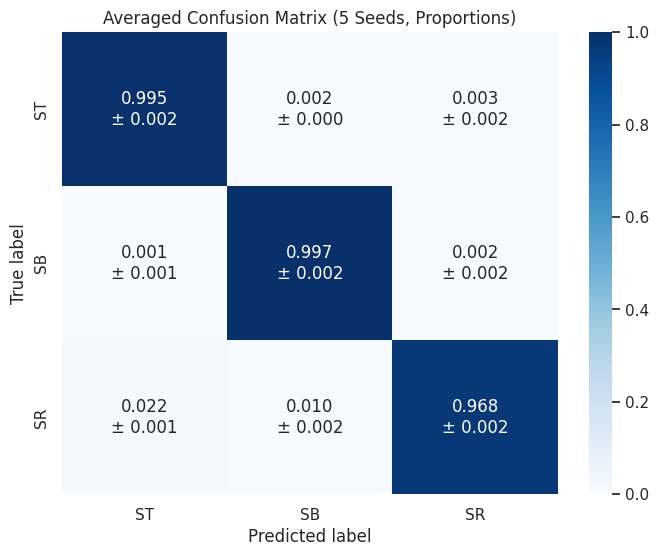

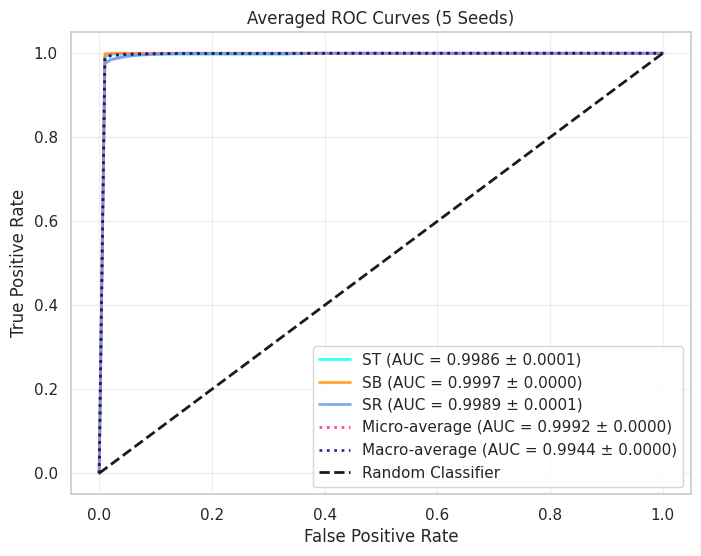

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9986 ± 0.0001
Class SB: 0.9997 ± 0.0000
Class SR: 0.9989 ± 0.0001
Micro-average: 0.9992 ± 0.0000
Macro-average: 0.9944 ± 0.0000
------------------------------



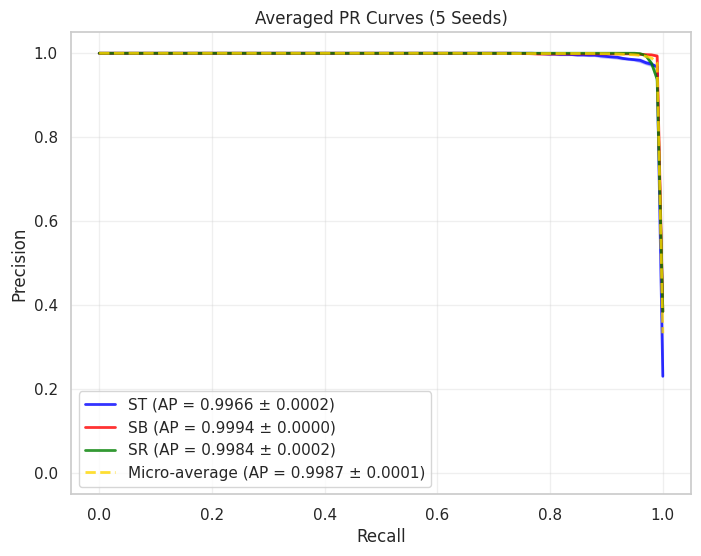

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm4/small_cnn_lr1e-3_perm4_val_acc_multiseed.png


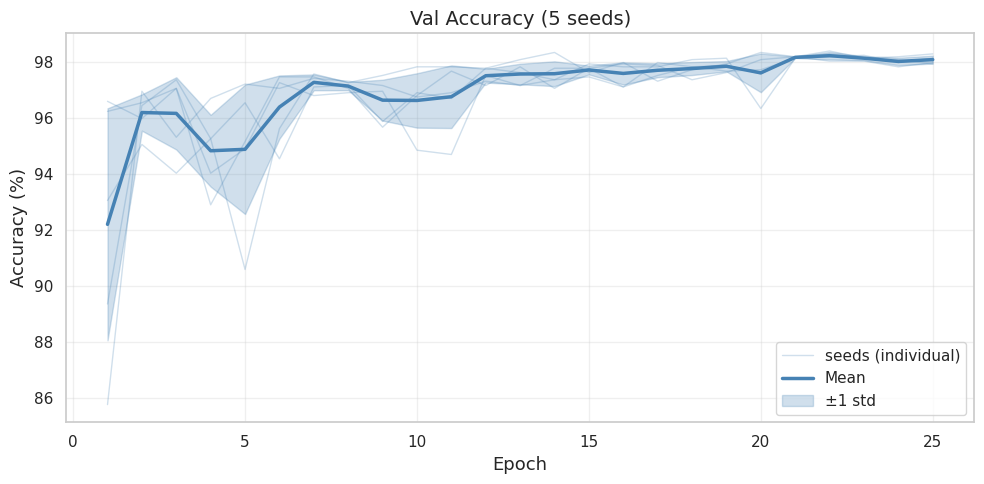

Saved: EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation/perm4/small_cnn_lr1e-3_perm4_val_loss_multiseed.png


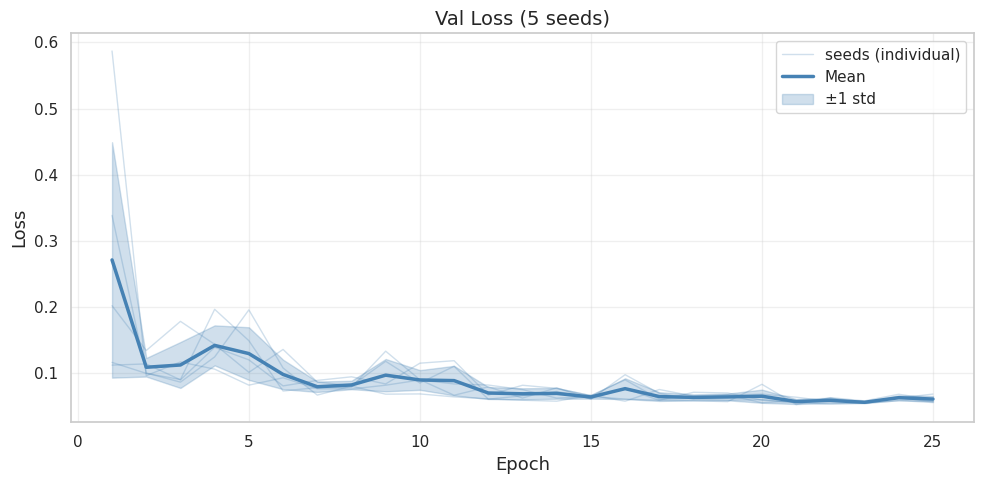

In [16]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)


In [1]:
import pandas as pd
import os

perms = ["perm1", "perm2", "perm3", "perm4"]
base = "EXPERIMENT_2d_leg_typ1_smallcnn_randomseed_permutation"
frames = []
for p in perms:
    nam = f"small_cnn_lr1e-3_{p}"
    path = os.path.join(base, p, f"{nam}_multiseed_summary.csv")
    if os.path.exists(path):
        df = pd.read_csv(path)

        # Drop the pre-baked "mean"/"std" summary rows that some pipelines
        # append at the bottom of the per-seed table under the "seed" column.
        # Keep only rows where "seed" is actually numeric.
        seed_numeric = pd.to_numeric(df["seed"], errors="coerce")
        df = df[seed_numeric.notna()].copy()
        df["seed"] = seed_numeric[seed_numeric.notna()].astype(int)

        df["perm"] = p
        frames.append(df)
    else:
        print("Missing:", path)

if not frames:
    raise FileNotFoundError("No summary CSVs found for any permutation.")

comparison = pd.concat(frames, ignore_index=True)
comparison.to_csv("comparison_multiseed_summary_all_perms.csv", index=False)

# show full table and simple aggregated stats by permutation
numeric_cols = comparison.select_dtypes(include="number").columns
numeric_cols = numeric_cols.drop("seed")  # don't average the seed id itself

display(comparison)
display(comparison.groupby("perm")[numeric_cols].agg(["mean", "std"]))

,seed,accuracy,f1_macro,f1_micro,auc_macro,ap_micro,perm
0,40,98.457584,0.983841,0.984576,0.998955,0.998523,perm1
1,41,98.303342,0.981938,0.983033,0.998555,0.998312,perm1
2,42,98.303342,0.982320,0.983033,0.998927,0.998584,perm1
3,43,98.200514,0.981415,0.982005,0.998846,0.998368,perm1
4,44,98.251928,0.981293,0.982519,0.998728,0.998352,perm1
5,40,97.892031,0.977554,0.978920,0.997888,0.997237,perm2
6,41,98.560411,0.984591,0.985604,0.998973,0.998523,perm2
7,42,98.406170,0.983401,0.984062,0.998985,0.998555,perm2
8,43,98.200514,0.980975,0.982005,0.998800,0.998294,perm2
9,44,97.892031,0.978111,0.978920,0.998512,0.998105,perm2


accuracy            f1_macro            f1_micro           auc_macro  \
            mean       std      mean       std      mean       std      mean   
perm                                                                           
perm1  98.303342  0.096187  0.982161  0.001026  0.983033  0.000962  0.998802   
perm2  98.190231  0.300672  0.980926  0.003116  0.981902  0.003007  0.998631   
perm3  98.293059  0.265666  0.982189  0.002660  0.982931  0.002657  0.998753   
perm4  98.550129  0.043016  0.984653  0.000478  0.985501  0.000430  0.999065   

                 ap_micro            
            std      mean       std  
perm                                 
perm1  0.000164  0.998428  0.000119  
perm2  0.000457  0.998143  0.000539  
perm3  0.000682  0.998346  0.000772  
perm4  0.000074  0.998699  0.000060